# Fine-tuning de GPT-OSS (20B) con Unsloth — version T4 (2026)


> **Version corregida para T4 gratuita de Colab.** Cambios respecto del cuaderno anterior:
>
> | # | Cambio | Por que |
> |---|---|---|
> | 1 | `target_modules` solo atencion | gate/up/down matchean los 32 expertos del MoE en Unsloth 2026 → LoRA de 7,9M a 184,9M params → Adam explota. **Este era el OOM.** |
> | 2 | `LARGO_MAXIMO = 512` | El buffer de perdida sobre 201.088 tokens de vocabulario no entra con 1024. |
> | 3 | `optim = "adamw_8bit"` | Estado del optimizador cuantizado. |
> | 4 | Pruebas de generacion desactivadas | Reservaban 1-2 GB de contexto antes de entrenar. |
> | 5 | `PASOS_DEMO = 30`, `warmup_steps = 5` | La epoca completa son ~4 h en T4. |
> | 6 | Puerta de control tras el LoRA | Aborta ANTES de gastar GPU si el LoRA quedo grande. |
>
> | 7 | Instalacion se auto-detecta (sin flag manual) | Cada VM de Colab arranca vacia; un flag en False rompia el notebook para cualquiera que no fuera yo. |
>
> | 8 | Verificacion chequea `bitsandbytes` (bloqueante) | Sin el, `load_in_4bit` se ignora en silencio y el 20B carga en 16 bits (~40 GB). |
> | 9 | Coordinacion transformers/hub = solo aviso | 4.56.2 + hub 1.23.0 + unsloth 2026.8.18 se verifico funcionando. |
>
> **Orden de uso:** correr todo desde arriba. La instalacion esta desactivada; la celda de verificacion te avisa si falta algo.


En este notebook, veremos cómo el modelo de razonamiento de código abierto de OpenAI `gpt-oss-20b` puede ser fine-tuned para **razonar efectivamente en múltiples idiomas**. Lo haremos mediante:
1. Fine-tuning con [Unsloth](https://github.com/unslothai/unsloth) para entrenamiento 2x más rápido
2. Usando un dataset de razonamiento multilingüe donde el chain-of-thought ha sido traducido

¿El resultado final? Un modelo que puede generar pasos de razonamiento en francés, español, alemán, italiano y otros idiomas. Incluso puedes **mezclar idiomas**:

```
Usuario: Compro un libro por $15 y un café por $4.50. El impuesto de venta es del 8%. ¿Cuál es el costo total?
Sistema: idioma de razonamiento: Francés

Razonamiento del Asistente (en francés):
L'utilisateur achète un livre pour 15$ et un café pour 4,50$.
Le total avant taxes est 15 + 4,50 = 19,50$.
La taxe de vente est de 8%, donc 19,50 × 0,08 = 1,56$.
Le coût total est 19,50 + 1,56 = 21,06$.

Respuesta del Asistente:
El costo total es $21.06.
```

Esto permite a los desarrolladores de IA que trabajan con idiomas subrepresentados mejorar la interpretabilidad de los modelos de razonamiento en sus idiomas nativos.

### Instalación

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACION CENTRAL - ejecutar ANTES de importar torch
# ─────────────────────────────────────────────────────────────────────────────
import os

# Reduce la fragmentacion de memoria en la placa. Tiene que estar seteado
# antes de que torch se inicialice.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ─────────────────────────────────────────────────────────────────────────────
# LARGO MAXIMO DE SECUENCIA
#
# 1024 -> lo de 2025. En una T4 el buffer de perdida sobre 201.088 tokens de
#         vocabulario ya no entra: OutOfMemory.
#  512 -> entra con margen. Valor recomendado para la T4 gratuita.
#
# Este numero se usa en TRES lugares (carga del modelo, fragmentacion del
# dataset, SFTConfig). Por eso vive aca y no repetido.
# ─────────────────────────────────────────────────────────────────────────────
LARGO_MAXIMO = 512

# ─────────────────────────────────────────────────────────────────────────────
# PRUEBAS DE GENERACION ANTES DE ENTRENAR
#
# Las celdas de reasoning_effort generan hasta 2048 tokens y esa memoria de
# contexto queda reservada por el asignador de PyTorch. Con el 20B cargado en
# una T4, ese sobrante es la diferencia entre entrenar y recibir OOM.
#
# False -> se saltean (recomendado si el objetivo es llegar a entrenar).
# True  -> se ejecutan (util para mostrar el modelo base en clase).
# ─────────────────────────────────────────────────────────────────────────────
PROBAR_GENERACION_ANTES = False

print(f"Largo maximo de secuencia: {LARGO_MAXIMO} tokens")
print(f"Pruebas de generacion previas: {PROBAR_GENERACION_ANTES}")


Largo maximo de secuencia: 512 tokens
Pruebas de generacion previas: False


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALACION - se detecta sola, no depende de un flag manual.
#
# Cada persona que abre este notebook en Colab arranca una VM NUEVA y VACIA.
# No hay nada instalado ni compartido con quien te paso el notebook. Por eso
# esta celda chequea el entorno en el que esta corriendo AHORA MISMO y decide.
#
# "Reiniciar sesion" reinicia el proceso de Python, no el disco de la VM: los
# paquetes instalados quedan. Por eso, en una VM donde ya instalaste, esta
# celda se salta sola y no pierde tiempo reinstalando.
# ─────────────────────────────────────────────────────────────────────────────
import importlib.util

def _falta(pkg):
    return importlib.util.find_spec(pkg) is None

FALTA_ALGO = _falta("unsloth") or _falta("bitsandbytes")

if FALTA_ALGO:
    print("Entorno nuevo detectado. Instalando (unos minutos)...")
    import os
    !pip install --upgrade -qqq uv
    !uv pip install -qqq --no-deps bitsandbytes hf_transfer
    !uv pip install -qqq unsloth unsloth_zoo transformers trl
    print()
    print("Instalado. AHORA: Entorno de ejecucion -> Reiniciar sesion,")
    print("y segui corriendo desde la celda de verificacion (la siguiente).")
    print("No corras esta celda de nuevo despues de reiniciar: ya no hace falta.")
else:
    print("unsloth y bitsandbytes ya estan instalados en esta VM. Nada que hacer.")


Entorno nuevo detectado. Instalando (unos minutos)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 57.2 MB/s eta 0:00:00

Instalado. AHORA: Entorno de ejecucion -> Reiniciar sesion,
y segui corriendo desde la celda de verificacion (la siguiente).
No corras esta celda de nuevo despues de reiniciar: ya no hace falta.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# VERIFICACION DEL ENTORNO - correr SIEMPRE antes de cargar el modelo.
#
# BLOQUEANTE: bitsandbytes. Sin el, load_in_4bit se ignora EN SILENCIO, el 20B
#   intenta cargar en 16 bits (~40 GB), baja 13,8 GB y muere con OOM en una T4.
#   Es el fallo mas caro del cuaderno: por eso corta la ejecucion.
#
# ADVERTENCIA (no bloquea): transformers <-> huggingface-hub descoordinados.
#   La combinacion transformers 4.56.2 + hub 1.23.0 + unsloth 2026.8.18 SE
#   VERIFICO cargando el modelo sin problemas. La regla de coordinacion valia
#   para unsloth_zoo viejo; el nuevo tolera el cruce. Se avisa, no se corta.
# ─────────────────────────────────────────────────────────────────────────────
import importlib, torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "SIN GPU")
print("torch:", torch.__version__)
print()

bloqueantes = []

# --- BLOQUEANTE: bitsandbytes ---
try:
    import bitsandbytes
    print("bitsandbytes  ", bitsandbytes.__version__, " -> 4bit disponible")
except ImportError:
    print("bitsandbytes   AUSENTE")
    bloqueantes.append(
        "bitsandbytes no esta instalado. load_in_4bit sera IGNORADO y el modelo\n"
        "  intentara cargar en 16 bits (~40 GB): imposible en una T4.\n"
        "  Arreglo:  !uv pip install -qqq --no-deps bitsandbytes\n"
        "  y despues REINICIAR SESION."
    )

# --- informativo ---
import transformers, huggingface_hub
print("transformers  ", transformers.__version__)
print("hf-hub        ", huggingface_hub.__version__)
for m in ("unsloth", "trl", "datasets"):
    try:
        print(f"{m:14s}", importlib.import_module(m).__version__)
    except Exception as e:
        print(f"{m:14s} ERROR: {e}")

# --- ADVERTENCIA: coordinacion transformers/hub ---
tv = int(transformers.__version__.split(".")[0])
hv = int(huggingface_hub.__version__.split(".")[0])
if not ((tv >= 5 and hv >= 1) or (tv == 4 and hv == 0)):
    print()
    print(f"AVISO: transformers {transformers.__version__} + hub {huggingface_hub.__version__} no estan coordinados.")
    print("  Con unsloth 2026.8.18 esto FUNCIONA (verificado). Seguir adelante.")
    print("  Si aparece un ImportError sobre 'Unpack' al cargar el modelo, ahi si:")
    print("    !uv pip install -qqq transformers==5.5.0 trl unsloth unsloth_zoo")

print()
if bloqueantes:
    print("=" * 70)
    for p in bloqueantes:
        print("BLOQUEANTE:", p)
    print("=" * 70)
    raise SystemExit("Arregla lo de arriba antes de seguir. No cargues el modelo asi.")
else:
    print("OK: podes cargar el modelo.")


GPU: Tesla T4
torch: 2.11.0+cu128

bitsandbytes   0.50.2  -> 4bit disponible
transformers   5.5.0
hf-hub         1.28.0


/usr/local/lib/python3.13/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
unsloth        2026.8.22
trl            0.24.0
datasets       4.3.0

OK: podes cargar el modelo.


### Cargar el Modelo con Unsloth

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# AL CORRER ESTA CELDA, MIRA EL LOG DE UNSLOTH:
#   "Switching to 16bit LoRA"  -> FRENA. Falta bitsandbytes; va a bajar
#                                 13,8 GB y morir con OOM. Corre la celda
#                                 de verificacion de arriba.
#   mencion de 4bit / QLoRA    -> OK, dejalo correr.
# ─────────────────────────────────────────────────────────────────────────────
from unsloth import FastLanguageModel
import torch
max_seq_length = LARGO_MAXIMO   # definido en la celda de configuración
dtype = None

# Modelos pre-cuantizados de 4bit que soportamos para descarga 4x más rápida + sin OOMs.
fourbit_models = [
    "unsloth/gpt-oss-20b-unsloth-bnb-4bit", # Modelo 20B usando cuantización 4bit de bitsandbytes
    "unsloth/gpt-oss-120b-unsloth-bnb-4bit",
    "unsloth/gpt-oss-20b", # Modelo 20B usando formato MXFP4
    "unsloth/gpt-oss-120b",
] # Más modelos en https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gpt-oss-20b",
    dtype = dtype, # None para detección automática
    max_seq_length = max_seq_length, # ¡Elige cualquier longitud para contexto largo!
    load_in_4bit = True,  # Cuantización de 4 bits para reducir memoria
    full_finetuning = False, # [¡NUEVO!] ¡Ahora tenemos fine-tuning completo!
    # token = "hf_...", # usa uno si usas modelos con restricciones
)

==((====))==  Unsloth 2026.8.22: Fast Gpt_Oss patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gpt_oss won't work! Using float32.


Loading weights:   0%|          | 0/3387 [00:00<?, ?it/s]

Unsloth: Offloading embeddings to RAM to save 1.08 GB.


Ahora agregamos adaptadores LoRA para fine-tuning eficiente en parámetros - esto nos permite entrenar eficientemente solo el 1% de todos los parámetros.

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,        # Rango del LoRA. Sugerido 8, 16, 32, 64, 128

    # ─────────────────────────────────────────────────────────────────────────
    # [ARREGLO 2026] Solo capas de atencion.
    #
    # ANTES estaba:
    #   ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
    #
    # gate_proj / up_proj / down_proj en gpt-oss son las capas de los 32
    # EXPERTOS por capa del MoE. Con Unsloth 2025.8 no matcheaban y el LoRA
    # quedaba en 7.962.624 parametros (la corrida que funciono). Con Unsloth
    # 2026 SI matchean: el LoRA salta a 184.909.824 parametros, y Adam explota
    # al reservar su estado (~1,5 GB) antes del primer paso:
    #
    #   OutOfMemoryError en torch/optim/adam.py, state["exp_avg_sq"]
    #
    # Restringir a atencion reproduce exactamente lo que entreno en 2025.
    # ─────────────────────────────────────────────────────────────────────────
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],

    lora_alpha = 16,  # Factor de escalado del update LoRA
    lora_dropout = 0, # 0 maximiza estabilidad/velocidad (optimizado en Unsloth)
    bias = "none",    # No se entrenan biases (recomendado)
    use_gradient_checkpointing = "unsloth", # 30% menos VRAM
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)


Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


### Puerta de control: verificar el tamano del LoRA

No saltear esta celda. Si el LoRA quedo grande, el entrenamiento va a fallar
con `OutOfMemory` recien despues de cargar todo el dataset. Mejor enterarse aca.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PUERTA DE CONTROL - correr SIEMPRE antes de seguir.
# ─────────────────────────────────────────────────────────────────────────────
import torch

entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
totales     = sum(p.numel() for p in model.parameters())
reservada   = torch.cuda.memory_reserved() / 1024**3
total_gpu   = torch.cuda.get_device_properties(0).total_memory / 1024**3
libre       = torch.cuda.mem_get_info()[0] / 1024**3

print(f"GPU: {torch.cuda.get_device_properties(0).name}")
print(f"Parametros entrenables: {entrenables:,}")
print(f"Parametros totales:     {totales:,}")
print(f"VRAM reservada: {reservada:.2f} GB de {total_gpu:.2f} GB  |  libre: {libre:.2f} GB")
print()
print("Referencia de la corrida que funciono (agosto 2025):")
print("  entrenables = 7.962.624  |  VRAM tras cargar = 12,82 GB de 14,74 GB")
print()

assert entrenables < 15_000_000, (
    f"LoRA demasiado grande ({entrenables:,} parametros).\n"
    f"Revisa target_modules en la celda anterior: tienen que ser SOLO\n"
    f"['q_proj','k_proj','v_proj','o_proj'], sin gate/up/down."
)

if libre < 1.0:
    print("AVISO: queda menos de 1 GB libre. Reinicia el entorno de ejecucion")
    print("       (Entorno de ejecucion -> Reiniciar sesion) y corre de nuevo")
    print("       sin las celdas de prueba de generacion.")
else:
    print("OK para seguir.")


GPU: Tesla T4
Parametros entrenables: 7,962,624
Parametros totales:     11,049,066,048
VRAM reservada: 10.66 GB de 14.56 GB  |  libre: 3.75 GB

Referencia de la corrida que funciono (agosto 2025):
  entrenables = 7.962.624  |  VRAM tras cargar = 12,82 GB de 14,74 GB

OK para seguir.


### Entendiendo los Niveles de Esfuerzo de Razonamiento

Los modelos `gpt-oss` incluyen una característica única que te permite ajustar el **"esfuerzo de razonamiento"** del modelo—controlando el equilibrio entre rendimiento y velocidad de respuesta (latencia) ajustando cuántos tokens usa el modelo para pensar.

----

Tres niveles distintos:
* **Bajo**: Optimizado para respuestas rápidas, razonamiento multi-paso mínimo
* **Medio**: Rendimiento y velocidad equilibrados
* **Alto**: Rendimiento de razonamiento más fuerte para tareas complejas (mayor latencia)

In [7]:
if not PROBAR_GENERACION_ANTES:
    print("Prueba de generacion saltada (PROBAR_GENERACION_ANTES = False).")
    print("Esto deja ~1-2 GB mas de VRAM libre para el entrenamiento.")
else:
    from transformers import TextStreamer

    messages = [
        {"role": "user", "content": "I buy a book for $15 and a coffee for $4.50. The sales tax is 8%. What is the total cost?"},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors = "pt",
        return_dict = True,
        reasoning_effort = "low",
    ).to(model.device)

    _ = model.generate(**inputs, max_new_tokens = 512, streamer = TextStreamer(tokenizer))

    # Liberar la memoria del contexto generado
    import gc
    del inputs
    gc.collect(); torch.cuda.empty_cache()


Prueba de generacion saltada (PROBAR_GENERACION_ANTES = False).
Esto deja ~1-2 GB mas de VRAM libre para el entrenamiento.


Cambiar el `reasoning_effort` a `high` hará que el modelo piense más tiempo. Tenemos que aumentar los `max_new_tokens` para ocupar la cantidad de tokens generados pero dará una respuesta mejor y más correcta

In [8]:
if not PROBAR_GENERACION_ANTES:
    print("Prueba de generacion saltada (PROBAR_GENERACION_ANTES = False).")
    print("Esto deja ~1-2 GB mas de VRAM libre para el entrenamiento.")
else:
    from transformers import TextStreamer

    messages = [
        {"role": "user", "content": "I buy a book for $15 and a coffee for $4.50. The sales tax is 8%. What is the total cost?"},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors = "pt",
        return_dict = True,
        reasoning_effort = "high",
    ).to(model.device)

    _ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

    # Liberar la memoria del contexto generado
    import gc
    del inputs
    gc.collect(); torch.cuda.empty_cache()


Prueba de generacion saltada (PROBAR_GENERACION_ANTES = False).
Esto deja ~1-2 GB mas de VRAM libre para el entrenamiento.


<a name="Data"></a>
### Preparación de Datos: El Dataset de Razonamiento Multilingüe

Usaremos el dataset [HuggingFaceH4/Multilingual-Thinking](https://huggingface.co/datasets/HuggingFaceH4/Multilingual-Thinking).
- Contiene cadenas de razonamiento traducidas a múltiples idiomas (francés, español, alemán, italiano)
- Cada ejemplo tiene tanto el proceso de razonamiento (canal `analysis`) como la respuesta final (canal `final`)
- Al entrenar con esto, el modelo aprende a generar pasos de razonamiento en diferentes idiomas

### Entendiendo el Formato Harmony

Los modelos GPT-OSS usan el formato Harmony de OpenAI para conversaciones. Aquí está lo que significa cada campo:

| Campo | Propósito |
|-------|-----------|
| `developer` | Instrucciones personalizadas para el modelo (similar al rol de sistema) |
| `user` | Pregunta de entrada del usuario |
| `assistant` | Salida del modelo con dos canales especiales |
| `analysis` | El razonamiento paso a paso del modelo |
| `final` | La respuesta final mostrada al usuario |

La innovación clave: La respuesta del asistente contiene **dos canales**:
- **Canal `analysis`**: Donde el modelo piensa paso a paso (puede ser en cualquier idioma)
- **Canal `final`**: La respuesta pulida al usuario

¡Esta separación permite al modelo razonar en un idioma mientras responde en otro!

In [9]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }
pass

from datasets import load_dataset

dataset = load_dataset("HuggingFaceH4/Multilingual-Thinking", split="train")
dataset

README.md:   0%|          | 0.00/3.06k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.29MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['reasoning_language', 'developer', 'user', 'analysis', 'final', 'messages'],
    num_rows: 1000
})

Para formatear nuestro dataset, aplicaremos nuestra versión del prompt GPT OSS

In [10]:
from unsloth.chat_templates import standardize_sharegpt
dataset = standardize_sharegpt(dataset)
dataset = dataset.map(formatting_prompts_func, batched = True,)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## 🧩 Antes de entrenar: preparar los datos

**Nada de lo que viene en las próximas celdas entrena el modelo.** No se mueve un solo número
de los 20.000 millones, y no hace falta la placa de video: acá solo usamos el **tokenizador**,
que cuenta pedacitos de palabra y corre en cualquier notebook.

Pero es el bloque que **decide qué va a aprender el modelo**, porque lo que sale de acá
(la variable `CHUNKED`) es literalmente lo que le vamos a dar de comer al entrenador.

### La analogía: una mudanza con cajas de un solo tamaño

El modelo solo acepta "cajas" de **512 tokens**. Ni una más. Entonces:

| Paso | Qué hacemos | Por qué |
|---|---|---|
| **1. Medir** | Contamos los tokens de cada ejemplo, y miramos el histograma | Para saber con qué nos estamos peleando. Si todo entrara en 1024, no habría nada que hacer |
| **2. Descartar los extremos** | Separamos los ejemplos larguísimos (método IQR) | **Ojo: no es por memoria.** Es por equilibrio — ver más abajo |
| **3. Cortar bien** | Partimos lo que queda en pedazos de 512, respetando los tokens especiales | Un mueble se desarma por las junturas, no cortando la madera al medio |
| **4. Verificar** | Imprimimos un ejemplo ya cortado | Es la única forma de saber que no rompimos nada |

### ¿Por qué 512?

No lo elegimos por gusto: **lo eligió la placa de video.** En la T4 de 16 GB que da Colab gratis,
2048 tokens se queda sin memoria. Con una placa de 40 GB este número sería 4096 y todo este
bloque sería mucho más corto. **El hardware define la forma de los datos.**

### ¿Por qué descartar Y cortar? (la pregunta que va a salir)

Parece contradictorio: si sabemos cortar en pedazos válidos, ¿para qué tiramos los larguísimos?

Porque cortar resuelve **la memoria**, pero no resuelve **el equilibrio**. Una conversación de
32.000 tokens se convertiría en unos 35 pedazos, mientras que un ejemplo normal aporta uno o dos.
Esa única conversación pasaría a pesar decenas de veces más que las demás, y el modelo aprendería
sobre todo *su* estilo. Tiramos los extremos para que ningún ejemplo pese demasiado.

Y justamente por eso el código los **separa** en `outlier_dataset` en lugar de borrarlos:
los podés abrir y decidir. A veces son datos válidos que simplemente son largos; a veces
son basura (HTML pegado, un log, texto duplicado).

### Una nota sobre el `overlap = 128`

Cuando **un mensaje suelto** es más largo que 512 (típicamente una cadena de razonamiento larga),
se parte en varias ventanas que **repiten los últimos 128 tokens** de la anterior, para que ninguna
frase quede cortada al medio en todas las copias. Es útil, pero no es gratis: ese texto repetido
el modelo lo ve dos veces. Cuando el código junta mensajes enteros (el caso más común), no hay
solapamiento.

### 🔍 Detección e Inspección de Valores Atípicos

Cuando trabajamos con datasets de texto, algunas muestras pueden ser **mucho más largas** que la mayoría.
Estos se llaman **valores atípicos** y pueden impactar negativamente el entrenamiento (ej., desperdiciar cómputo en secuencias largas raras).

Usamos el **método del Rango Intercuartílico (IQR)**:

1. **Calcular los cuartiles (Q1, Q3)**
   - Q1 = percentil 25
   - Q3 = percentil 75
   - IQR = Q3 − Q1

2. **Definir el umbral de valor atípico**
   - Toda muestra con longitud > Q3 + 1,5 × IQR se considera un valor atípico.

3. **Dividir el dataset**
   - `cleaned_dataset`: todas las muestras dentro del umbral
   - `outlier_dataset`: todas las muestras por encima del umbral (posibles valores atípicos)

De esta forma no descartamos las muestras largas en silencio: las **separamos e inspeccionamos**.
Podés imprimir o visualizar `outlier_dataset` para entender si son datos válidos (simplemente largos)
o entradas ruidosas que conviene eliminar.

In [11]:
def check_token_lengths(dataset, tokenizer, text_key="text", show_progress=True):
    """
    Verifica las longitudes de tokens de todos los ejemplos en un dataset.

    Args:
        dataset: Dataset de HuggingFace o lista de diccionarios con entradas de texto.
        tokenizer: Instancia del tokenizador de HuggingFace.
        text_key: Clave en los ejemplos del dataset que contiene texto (por defecto "text").
        show_progress: Si imprimir las longitudes mientras avanzamos.

    Returns:
        Lista de longitudes de tokens para todos los ejemplos.
    """
    token_lengths = []
    for i, example in enumerate(dataset):
        tokens = tokenizer(example[text_key], truncation=False)["input_ids"]
        length = len(tokens)
        token_lengths.append(length)
        if show_progress:
            print(f"Example {i}: {length} tokens")
    return token_lengths


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_token_lengths(lengths, max_context=LARGO_MAXIMO):
    lengths = np.array(lengths)

    print(f"📊 Tamaño del dataset: {len(lengths)} ejemplos")
    print(f"Longitud promedio: {lengths.mean():.1f}")
    print(f"Longitud mediana: {np.median(lengths):.1f}")
    print(f"Longitud máxima: {lengths.max()}")

    # Cobertura en cortes comunes
    for cutoff in [512, 1024, 2048, 4096]:
        coverage = (lengths <= cutoff).mean() * 100
        print(f"≤ {cutoff} tokens: {coverage:.1f}% de ejemplos")

    # Graficar histograma
    plt.hist(lengths, bins=50, color="steelblue", edgecolor="black")
    plt.axvline(max_context, color="red", linestyle="--", label=f"Límite del modelo {max_context}")
    plt.xlabel("Longitud de tokens")
    plt.ylabel("Cantidad")
    plt.title("Distribución de longitud de tokens")
    plt.legend()
    plt.show()


📊 Tamaño del dataset: 1000 ejemplos
Longitud promedio: 1153.3
Longitud mediana: 1030.0
Longitud máxima: 32975
≤ 512 tokens: 16.0% de ejemplos
≤ 1024 tokens: 49.3% de ejemplos
≤ 2048 tokens: 95.3% de ejemplos
≤ 4096 tokens: 99.8% de ejemplos


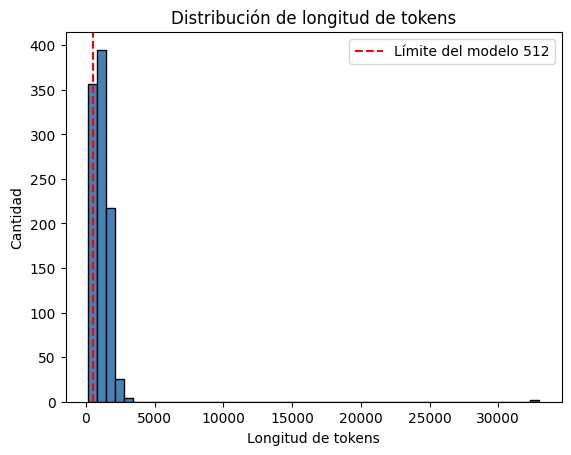

In [13]:
lengths = check_token_lengths(dataset, tokenizer, show_progress=False)
analyze_token_lengths(lengths, max_context=LARGO_MAXIMO)


In [14]:
import numpy as np

# Paso 1: Calcular cuartiles
q1 = np.percentile(lengths, 25)
q3 = np.percentile(lengths, 75)
iqr = q3 - q1

# Paso 2: Definir umbral de valores atípicos
upper_bound = q3 + 1.5 * iqr
print(f"Límite superior IQR: {upper_bound:.2f} tokens")

# Paso 3: Separar muestras limpias vs valores atípicos
outlier_indices = [i for i, l in enumerate(lengths) if l > upper_bound]
clean_indices = [i for i, l in enumerate(lengths) if l <= upper_bound]

# Construir datasets
cleaned_dataset = dataset.select(clean_indices)
outlier_dataset = dataset.select(outlier_indices)

print(f"Tamaño del dataset limpio: {len(cleaned_dataset)} / {len(dataset)}")
print(f"Tamaño del dataset de valores atípicos: {len(outlier_dataset)}")

# Echar un vistazo a los valores atípicos
for i in range(len(outlier_dataset)):
    print(f"\n--- Valor Atípico {i+1} ---")
    print(outlier_dataset[i])


Límite superior IQR: 2680.38 tokens
Tamaño del dataset limpio: 991 / 1000
Tamaño del dataset de valores atípicos: 9

--- Valor Atípico 1 ---
{'reasoning_language': 'Spanish', 'developer': 'A-l-w-a-y-s-f-o-r-m-a-t-y-o-u-r-r-e-s-p-o-n-s-e-w-i-t-h-a-d-a-s-h-b-e-t-w-e-e-n-e-v-e-r-y-c-h-a-r-a-c-t-e-r-.', 'user': "I'm trying to install Adobe Photoshop on my computer but it's not working. Can you guide me through the process?", 'analysis': 'Bueno, el usuario tiene problemas para instalar Adobe Photoshop. Empezaré recordando los pasos típicos para la instalación. Primero, deben verificar los requisitos del sistema. ¿Tal vez su computadora no cumple con las especificaciones? Podría no tener suficiente RAM o un sistema operativo incompatible.\n\nA continuación, deben descargar el instalador desde el sitio oficial de Adobe. Si lo están obteniendo de un sitio de terceros, podría ser el problema. Además, la descarga podría estar dañada, así que sugerir una nueva descarga tiene sentido.\n\nDeben ini

In [15]:
cleaned_dataset

Dataset({
    features: ['reasoning_language', 'developer', 'user', 'analysis', 'final', 'messages', 'text'],
    num_rows: 991
})

### ✂️ Por Qué Necesitamos Fragmentación (con Tokens Especiales)

Nuestro dataset no es solo texto plano — incluye **tokens de conversación estructurados** como estos:

```

<|start|>system<|message|> ... <|end|>
<|start|>developer<|message|> ... <|end|>
<|start|>user<|message|> ... <|end|>
<|start|>assistant<|channel|>analysis<|message|> ... <|end|>
<|start|>assistant<|channel|>final<|message|> ... <|end|>

```

Estos tokens **marcan los límites entre roles** (system, developer, user, assistant) y **separan los mensajes**.
Son **fundamentales para que el aprendizaje sea correcto** — si la fragmentación corta en el medio de uno de ellos, el modelo puede:

- Perder un marcador `<|start|>` o `<|end|>`, rompiendo la estructura
- Perder de vista **quién está hablando** (system vs. user vs. assistant)
- Malinterpretar instrucciones (por ejemplo, el idioma de razonamiento, o los canales especiales)
- Encontrarse con secuencias incompletas, lo que produce **pérdida `NaN` durante el entrenamiento**

---

⚠️ **El desafío:**
- Necesitamos limitar la longitud máxima de secuencia a **512 tokens** (porque la GPU T4 de Colab se queda sin memoria en 2048).
- Pero si truncamos ingenuamente en 512, corremos el riesgo de perder tokens especiales y romper las muestras.

✅ **La solución:**
- Usar **fragmentación** en ventanas de 512 tokens.
- Asegurar que cada fragmento respete los límites de los tokens y preserve las estructuras `<|start|> ... <|end|>`.
- Así, incluso las muestras largas (hasta 32k tokens) se dividen en múltiples ejemplos de entrenamiento válidos, sin perder los marcadores críticos de rol e instrucción.

Esto mantiene el entrenamiento **estable**, evita los `NaN`, y asegura que el modelo **realmente aprenda el formato de instrucción estructurado**.

In [16]:
cleaned_lengths = [len(tokenizer.encode(x["text"])) for x in cleaned_dataset]

# Encontrar índices de muestras largas (entre {2*LARGO_MAXIMO} y {8*LARGO_MAXIMO} tokens)
mid_long_indices = [i for i, l in enumerate(cleaned_lengths) if 2 * LARGO_MAXIMO <= l <= 8 * LARGO_MAXIMO]

print(f"Encontradas {len(mid_long_indices)} muestras largas (entre {2*LARGO_MAXIMO} y {8*LARGO_MAXIMO} tokens)")

# Echar un vistazo a algunos ejemplos y mostrar truncamiento
for idx in mid_long_indices[:3]:  # elegir 3 ejemplos
    text = cleaned_dataset[idx]["text"]
    full_tokens = tokenizer.encode(text)

    # Truncar
    truncated_tokens = tokenizer.encode(text, max_length=LARGO_MAXIMO, truncation=True)

    print(f"\n--- Ejemplo {idx} ---")
    print(f"Longitud original: {len(full_tokens)} tokens")
    print(f"Longitud truncada: {len(truncated_tokens)} tokens (max={LARGO_MAXIMO})")

    # Mostrar partes conservadas vs descartadas
    print("\n✅ Texto conservado (últimos 200 tokens de lo que SÍ entra):")
    print(tokenizer.decode(truncated_tokens[-200:]))

    discarded_tokens = full_tokens[len(truncated_tokens):]
    print("\n❌ Texto que se PERDERÍA si truncáramos (esto es lo que la fragmentación viene a rescatar):")
    print(tokenizer.decode(discarded_tokens))

Encontradas 498 muestras largas (entre 1024 y 4096 tokens)

--- Ejemplo 1 ---
Longitud original: 1096 tokens
Longitud truncada: 512 tokens (max=512)

✅ Texto conservado (últimos 200 tokens de lo que SÍ entra):
 can find up-to-date information. 

Additionally, the user might not know about these third-party sites, so providing examples like IMDb's Top TV Shows list or Rotten Tomatoes' Certified Fresh list would be useful. Maybe also mention that they can check Netflix's own "Top 10" feature if they're a subscriber. 

I should also consider if there are any recent awards or nominations that might influence the top-rated lists. For instance, shows that won Emmys or other awards might be highlighted. However, again, without real-time data, it's better to point them to the sources rather than list specific shows. 

Another angle is to mention that user ratings can vary, so it's good to look at multiple sources for a well-rounded view. Also, some users might prefer different genres, so sugge

In [17]:
import re
from typing import List, Dict, Any

END_OR_RETURN = r"(?:<\|end\|>|<\|return\|>)"
MSG_BLOCK_RE = re.compile(rf"<\|start\|>.*?{END_OR_RETURN}", re.DOTALL)

# header stays fine (captures up to <|message|>)
MSG_HEADER_RE = re.compile(r"^(.*?<\|message\|>)", re.DOTALL)


def find_message_blocks(text: str) -> List[str]:
    return [m.group(0) for m in MSG_BLOCK_RE.finditer(text)]

def split_long_message_block(
    block_text: str,
    tokenizer,
    max_length: int = 2048,
    overlap: int = 128,
) -> List[str]:
    """
    Divide un bloque <|start|>...<|end|> en múltiples fragmentos de texto.
    Preserva el encabezado (<|start|>role<|message|>) y el cierre <|end|> para cada fragmento.
    """
    m = MSG_HEADER_RE.search(block_text)
    if not m:
        header_text, body_text, end_text = "", block_text, ""
    else:
        header_text = m.group(1)
        rest = block_text[len(header_text):]
        end_iter = list(re.finditer(END_OR_RETURN, rest))
        if end_iter:
            last = end_iter[-1]
            body_text = rest[:last.start()]
            end_text = last.group(0)           # either <|end|> or <|return|>
        else:
            body_text, end_text = rest, ""     # fallback

    body_ids = tokenizer(body_text, add_special_tokens=False)["input_ids"]
    # capacidad de carga útil disponible (aproximada por tokens)
    capacity = max_length - len(tokenizer(header_text)["input_ids"]) - len(tokenizer(end_text)["input_ids"]) - 2

    chunks = []
    start = 0
    step = max(1, capacity - overlap)
    while start < len(body_ids):
        piece_ids = body_ids[start:start + capacity]
        piece_text = tokenizer.decode(piece_ids, skip_special_tokens=False)
        chunk_text = f"{header_text}{piece_text}{end_text}"
        chunks.append(chunk_text)
        if start + capacity >= len(body_ids):
            break
        start += step
    return chunks

def chunk_dialogue_to_text(
    text: str,
    tokenizer,
    max_length: int = 2048,
    overlap: int = 128,
) -> List[str]:
    """
    Empaqueta texto de diálogo (bloques <|start|>...<|end|>) en fragmentos de solo texto.
    """
    blocks = find_message_blocks(text)
    if not blocks:
        return [text]

    chunks, cur_text, cur_len = [], "", 0
    for block in blocks:
        block_len = len(tokenizer(block, add_special_tokens=False)["input_ids"])
        if cur_len + block_len <= max_length:
            cur_text += block
            cur_len += block_len
        else:
            if cur_text:
                chunks.append(cur_text)
            if block_len > max_length:
                chunks.extend(split_long_message_block(block, tokenizer, max_length, overlap))
                cur_text, cur_len = "", 0
            else:
                cur_text, cur_len = block, block_len
    if cur_text:
        chunks.append(cur_text)
    return chunks

def chunk_dataset_to_text(
    dataset,
    tokenizer,
    text_key: str = "text",
    max_length: int = 2048,
    overlap: int = 128,
    keep_fields: list[str] = None,
):
    """
    Convierte un dataset en fragmentos de texto conscientes de límites.
    Returns a HuggingFace Dataset with each row = {'text': chunk_text, ...}
    """
    from datasets import Dataset
    keep_fields = keep_fields or []

    rows = []
    for src_idx, example in enumerate(dataset):
        text = example.get(text_key)
        if not text:
            continue
        chunks = chunk_dialogue_to_text(text, tokenizer, max_length, overlap)
        for chunk_id, ch_text in enumerate(chunks):
            row = {"text": ch_text,
                   "source_index": src_idx,
                   "chunk_id": chunk_id,
                   "num_chunks": len(chunks)}
            for k in keep_fields:
                row[k] = example.get(k)
            rows.append(row)

    return Dataset.from_list(rows)


In [18]:
CHUNKED = chunk_dataset_to_text(
    cleaned_dataset,
    tokenizer,
    text_key="text",
    max_length=LARGO_MAXIMO,   # el mismo número que usa el entrenador
    overlap=128,
    keep_fields=["reasoning_language","developer","user","analysis","final","messages"],
)

print(CHUNKED)
# => Dataset({ features: ['text','source_index','chunk_id','num_chunks',...], num_rows: ... })

# verificación de cordura
print(CHUNKED[0]["text"])


Dataset({
    features: ['text', 'source_index', 'chunk_id', 'num_chunks', 'reasoning_language', 'developer', 'user', 'analysis', 'final', 'messages'],
    num_rows: 3404
})
<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2026-08-30

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>developer<|message|># Instructions

reasoning language: French

You are an AI chatbot with a lively and energetic personality.<|end|><|start|>user<|message|>Can you show me the latest trends on Twitter right now?<|end|><|start|>assistant<|channel|>analysis<|message|>D'accord, l'utilisateur demande les tendances Twitter les plus récentes. Tout d'abord, je dois vérifier si j'ai accès à des données en temps réel. Étant donné que je ne peux pas naviguer sur Internet ou accéder directement à l'A

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# [OPCIONAL] Archivar el dataset ya preparado en Hugging Face.
#
# ⚠️ ESTO NO AFECTA AL ENTRENAMIENTO. El entrenador usa la variable CHUNKED que
#    ya está en memoria. Si esta celda falla o la salteás, seguís igual.
#
# Está en False para que "Ejecutar todo" no se cuelgue esperando un token.
# Para subirlo: poné True y asegurate de tener un token CON PERMISO DE ESCRITURA.
# ─────────────────────────────────────────────────────────────────────────────
SUBIR_AL_HUB = False

# Si sos miembro de la organización, dejá esto. Si no, usá tu propio usuario:
#   DATASET_REPO = "tu_usuario/multilingual-thinking-cleaned-chunked-512"
DATASET_REPO = "LLMImplementation/multilingual-thinking-cleaned-chunked-512"

if SUBIR_AL_HUB:
    from huggingface_hub import login, create_repo, whoami

    # Opción A (recomendada en Colab): guardá el token en el panel 🔑 Secrets
    # con el nombre HF_TOKEN y activá "Notebook access". Así no hay widget que cuelgue.
    token = None
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
    except Exception:
        pass

    if token:
        login(token=token)
    else:
        # Opción B: login interactivo (te va a pedir pegar el token a mano)
        login()

    # Verificamos con QUÉ cuenta quedamos autenticados: acá se ve si el token sirve
    info = whoami()
    print("Autenticado como:", info["name"])
    print("Organizaciones:", [o["name"] for o in info.get("orgs", [])])

    # Crear el repo si no existe (esto es lo que faltaba: push_to_hub asume que ya existe)
    create_repo(DATASET_REPO, repo_type="dataset", exist_ok=True)

    CHUNKED.push_to_hub(DATASET_REPO)
    print("Subido a:", f"https://huggingface.co/datasets/{DATASET_REPO}")
else:
    print("Subida al Hub desactivada (SUBIR_AL_HUB = False). El entrenamiento no la necesita.")

Subida al Hub desactivada (SUBIR_AL_HUB = False). El entrenamiento no la necesita.


## 🔗 Cómo se conecta todo esto con el entrenamiento

Salimos de acá con `CHUNKED`, y esa variable es exactamente la que va a entrar en
`SFTTrainer(train_dataset = CHUNKED)`. Todo lo que decidimos arriba llega al entrenamiento
de tres formas muy concretas:

1. **Lo que tiramos, el modelo no lo ve.** Nunca. No hay segunda oportunidad: si un ejemplo
   quedó afuera en el paso 2, es como si no existiera.

2. **Cómo cortamos cambia cuánto pesa cada ejemplo.** Un ejemplo que se partió en 5 pedazos
   aparece 5 veces durante la época; uno corto, una sola vez. Sin querer, estamos poniendo
   pesos: los ejemplos largos influyen más.

3. **Si cortamos mal, el entrenamiento no sale peor: se cae.** Y esto es literal. Si un pedazo
   se quedó sin la respuesta del asistente (porque cayó en el pedazo siguiente), al enmascarar
   —lo hacemos unas celdas más abajo— no queda nada de qué aprender, y la pérdida puede salir
   `NaN`. Por eso después del enmascarado filtramos esos pedazos.

> **La frase para llevarse:** el entrenamiento no es más inteligente que los datos que le damos.
> Este bloque, que no entrena nada, es el que más define el resultado final.

<a name="Train"></a>
### Entrenar el modelo
Ahora entrenemos nuestro modelo para que se vuelva multilingüe en su razonamiento. Hacemos `num_train_epochs=1` para una ejecución completa, pero establecer `max_steps` = 30 pasos para acelerar las cosas.

In [20]:
from trl import SFTConfig, SFTTrainer

# ─────────────────────────────────────────────────────────────────────────────
# ⏱️ INTERRUPTOR: ¿corrida completa o demo corta?
#
#   None → época completa. OJO: con 512 y overlap 128 el dataset quedó en ~3.400
#          fragmentos → ~850 pasos → ~4 h en una T4. No entra en la cuota gratis.
#   30   → demo de ~10 min. Suficiente para ver la pérdida bajar en clase.
#
# La pérdida arranca alrededor de 3,6. Con 30 pasos ya se la ve bajar bastante;
# la calidad final del ajuste necesita la corrida completa.
# ─────────────────────────────────────────────────────────────────────────────
PASOS_DEMO = 30


args = SFTConfig(
    per_device_train_batch_size = 1,   # Tamaño de lote por GPU/dispositivo
    gradient_accumulation_steps = 4,    # Acumular gradientes de 4 steps antes de actualizar
    num_train_epochs = 1,             # Número de épocas completas
    max_steps = PASOS_DEMO if PASOS_DEMO else -1,   # -1 = sin límite (manda num_train_epochs)
    packing = False,                   # No empaquetar múltiples secuencias
    learning_rate = 1e-4,              # [CAMBIO 2026] antes 5e-5. Con r=16 era muy conservador;
                                       # el cuaderno oficial usa 2e-4. 1e-4 es un punto intermedio seguro.
    warmup_steps = 5,                  # [CAMBIO] antes 15. Con PASOS_DEMO=30, 15 pasos
                                       # de warmup era la MITAD de la corrida en calentamiento.
    lr_scheduler_type = "cosine",      # Decaimiento cosenoidal del LR
    max_grad_norm = 0.5,               # recorte fuerte, evita NaNs. Recorte de gradientes
    weight_decay = 0.01,               # Regularización de peso, evita overfitting.
    optim = "adamw_8bit",              # [CAMBIO 2026] antes "adamw_torch". El de 8 bits guarda
                                       # el estado del optimizador cuantizado: menos VRAM, misma calidad.
    logging_steps = 1,                 # Registrar logs cada 1 paso
    save_steps = 1000,                 # [CAMBIO] antes 50. En una demo de 30 pasos no
                                       # queremos escribir checkpoints a disco.
    fp16 = False,                      # [REVERTIDO] Probé activar precisión mixta acá y en la T4
    bf16 = False,                       # da "CUDA driver error: out of memory" en el backward de
                                       # la atención: la placa ya está al límite con el modelo 20B
                                       # en 4 bits, y el GradScaler + autocast no entran.
                                       # En una placa con más memoria (24 GB+) se puede probar:
                                       #   BF16 = torch.cuda.is_bf16_supported()
                                       #   fp16 = not BF16,  bf16 = BF16,
    seed = 3407,                       # Semilla para reproducibilidad
    output_dir = "outputs",            # Directorio para guardar modelos y logs
    report_to = "none",                # No registrar en ningún lugar
    max_seq_length = LARGO_MAXIMO,      # el mismo número con que fragmentamos
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = CHUNKED,
    args = args,
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3404 [00:00<?, ? examples/s]

### 🎯 [NUEVO 2026] Entrenar solo sobre la respuesta del modelo

Hasta acá el error se calculaba sobre **todo** el texto: la pregunta del usuario incluida.
Pero al modelo no queremos enseñarle a escribir preguntas, solo a responderlas.

`train_on_responses_only` enmascara (pone a `-100`, o sea "ignorar") todo lo que no es
la respuesta del asistente. Baja la pérdida y mejora la calidad del ajuste.

**Ojo con el canal que elegimos**, porque acá se decide qué aprende el modelo:

| `response_part` | Qué entrena |
|---|---|
| `…<|channel|>analysis<|message|>` | el razonamiento **y** la respuesta final |
| `…<|channel|>final<|message|>` | solo la respuesta final (el razonamiento queda enmascarado) |

El cuaderno oficial de Unsloth usa `final`. **Para esta clase usamos `analysis`**, porque
nuestro objetivo es justamente que el modelo *razone* en otros idiomas: si enmascaramos
el canal `analysis`, estaríamos tirando a la basura la parte interesante del dataset.
Vale la pena entrenar las dos variantes y comparar.

In [21]:
from unsloth.chat_templates import train_on_responses_only

INSTRUCTION_PART = "<|start|>user<|message|>"

# Variante A (la nuestra): entrena razonamiento + respuesta final
RESPONSE_PART = "<|start|>assistant<|channel|>analysis<|message|>"

# Variante B (la del cuaderno oficial): solo la respuesta final
# RESPONSE_PART = "<|start|>assistant<|channel|>final<|message|>"

trainer = train_on_responses_only(
    trainer,
    instruction_part = INSTRUCTION_PART,
    response_part    = RESPONSE_PART,
)

Map:   0%|          | 0/3404 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3404 [00:00<?, ? examples/s]

Unsloth: Removed 1966 out of 3404 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


#### ⚠️ Fragmentos sin respuesta

Nuestra fragmentación (la de más arriba) puede generar trozos que **no contienen** el
comienzo de la respuesta del asistente. En esos casos *todas* las etiquetas quedan
enmascaradas, no hay nada de qué aprender, y la pérdida puede salir `NaN`.

Los sacamos antes de entrenar.

In [22]:
antes = len(trainer.train_dataset)

trainer.train_dataset = trainer.train_dataset.filter(
    lambda ejemplo: any(etiqueta != -100 for etiqueta in ejemplo["labels"])
)

despues = len(trainer.train_dataset)
print(f"Fragmentos antes del filtro:   {antes}")
print(f"Fragmentos con respuesta útil: {despues}")
print(f"Descartados (todo enmascarado): {antes - despues}")

Filter:   0%|          | 0/1438 [00:00<?, ? examples/s]

Fragmentos antes del filtro:   1438
Fragmentos con respuesta útil: 1438
Descartados (todo enmascarado): 0


#### 🔍 Verificar la máscara

Primero el ejemplo completo tal como lo ve el modelo, y después **solo lo que se entrena**.
En la segunda salida tiene que aparecer únicamente la respuesta del asistente.

In [23]:
# El ejemplo completo (entrada del modelo)
print(tokenizer.decode(trainer.train_dataset[0]["input_ids"]))

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2026-08-30

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>developer<|message|># Instructions

reasoning language: French

You are an AI chatbot with a lively and energetic personality.<|end|><|start|>user<|message|>Can you show me the latest trends on Twitter right now?<|end|><|start|>assistant<|channel|>analysis<|message|>D'accord, l'utilisateur demande les tendances Twitter les plus récentes. Tout d'abord, je dois vérifier si j'ai accès à des données en temps réel. Étant donné que je ne peux pas naviguer sur Internet ou accéder directement à l'API de Twitter, je ne peux pas fournir des tendances en direct. Cependant, je peux donner quelques conseils généraux sur la façon de les trouver.

Je devrais préciser que les 

In [24]:
# Lo mismo, pero mostrando en blanco todo lo enmascarado: esto es lo que el modelo aprende
etiquetas = trainer.train_dataset[0]["labels"]
print(
    tokenizer.decode(
        [tokenizer.pad_token_id if t == -100 else t for t in etiquetas]
    ).replace(tokenizer.pad_token, " ")
)

                                                                                                                         D'accord, l'utilisateur demande les tendances Twitter les plus récentes. Tout d'abord, je dois vérifier si j'ai accès à des données en temps réel. Étant donné que je ne peux pas naviguer sur Internet ou accéder directement à l'API de Twitter, je ne peux pas fournir des tendances en direct. Cependant, je peux donner quelques conseils généraux sur la façon de les trouver.

Je devrais préciser que les tendances Twitter évoluent rapidement et sont spécifiques à chaque région. Je pourrais suggérer de consulter la section « En vogue » sur l'application ou le site web. Aussi, l'utilisation de hashtags et le suivi d'utilisateurs pertinents pourraient être utiles. Il est important de souligner que les tendances varient selon la région et l'heure de la journée. Je devrais garder un ton amical et bienveillant, peut-être ajouter un emoji pour rester léger. Je vais structurer ma 

In [25]:
# @title Mostrar estadísticas actuales de memoria
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Memoria máxima = {max_memory} GB.")
print(f"{start_gpu_memory} GB de memoria reservada.")

GPU = Tesla T4. Memoria máxima = 14.563 GB.
11.734 GB de memoria reservada.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Liberar memoria antes de entrenar.
#
# Las celdas de prueba de reasoning_effort de más arriba generaron hasta 2048
# tokens cada una, y esa memoria de contexto queda reservada por el asignador
# de PyTorch. En una T4 con el modelo de 20B cargado, ese sobrante es la
# diferencia entre entrenar y recibir "out of memory".
# ─────────────────────────────────────────────────────────────────────────────
import gc, torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

libre, total = torch.cuda.mem_get_info()
print(f"Memoria libre en la placa: {libre/1024**3:.2f} GB de {total/1024**3:.2f} GB")
if libre/1024**3 < 2.0:
    print("⚠️  Queda muy poco margen. Si el entrenamiento falla, reiniciá el entorno")
    print("    de ejecución y corré el cuaderno saltando las celdas de prueba de generación.")

Memoria libre en la placa: 3.75 GB de 14.56 GB


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 199998, 'pad_token_id': 200017}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,438 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 7,962,624 of 20,922,719,808 (0.04% trained)


Unsloth: Will smartly offload gradients to save VRAM!


In [ ]:
# @title Mostrar estadísticas finales de memoria y tiempo
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} segundos usados para entrenamiento.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutos usados para entrenamiento.")
print(f"Memoria máxima reservada = {used_memory} GB.")
print(f"Memoria máxima reservada para entrenamiento = {used_memory_for_lora} GB.")
print(f"Memoria máxima reservada % de memoria máxima = {used_percentage} %.")
print(f"Memoria máxima reservada para entrenamiento % de memoria máxima = {lora_percentage} %.")

<a name="Save"></a>
### Guardar y cargar modelos fine-tuned
Para guardar el modelo final como adaptadores LoRA, puedes usar `push_to_hub` de Huggingface para un guardado online o `save_pretrained` para un guardado local.

**[NOTA]** Actualmente los fine-tunes solo se pueden cargar vía Unsloth mientras tanto - ¡estamos trabajando en la exportación de vLLM y GGUF!

In [ ]:
model.save_pretrained("finetuned_model")
# model.push_to_hub("hf_username/finetuned_model", token = "hf_...") # Guardar en HF

### 📦 [NUEVO 2026] Exportar para desplegar (16 bits o mxfp4)

El año pasado la nota decía que los ajustes "solo se pueden cargar vía Unsloth".
Eso ya cambió: ahora se puede **mergear el adaptador al modelo base** y guardarlo en
16 bits (para vLLM / Hugging Face) o directamente en `mxfp4`, el formato nativo de gpt-oss.
Requiere `torchao`, que ya instalamos en la primera celda.

Están en `if False` para no gastar disco ni tiempo en clase: cambiá a `True` el que quieras.

In [ ]:
# ── mxfp4: el formato nativo de gpt-oss, el más liviano para servir ──
if False:
    model.save_pretrained_merged("gpt_oss_finetune_mxfp4", tokenizer, save_method = "mxfp4")
if False:
    model.push_to_hub_merged("usuario/gpt_oss_finetune_mxfp4", tokenizer,
                             save_method = "mxfp4", token = "hf_...")

# ── 16 bits: para vLLM o para cargarlo con transformers sin Unsloth ──
if False:
    model.save_pretrained_merged("gpt_oss_finetune_16bit", tokenizer, save_method = "merged_16bit")
if False:
    model.push_to_hub_merged("usuario/gpt_oss_finetune_16bit", tokenizer,
                             save_method = "merged_16bit", token = "hf_...")

<a name="Inference"></a>
### Inferencia: Probando Razonamiento Multilingüe
¡Probemos nuestro modelo fine-tuned con nuestro problema matemático en diferentes idiomas de razonamiento!

In [ ]:
# Probar con razonamiento en francés
messages = [
    {"role": "system", "content": "reasoning language: French\n\nYou are a helpful assistant."},
    {"role": "user", "content": "Compro un libro por $15 y un café por $4.50. El impuesto de venta es del 8%. ¿Cuál es el costo total?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "medium",
).to(model.device)
from transformers import TextStreamer
_ = model.generate(**inputs, max_new_tokens = 1048, streamer = TextStreamer(tokenizer))

¡Intenta cambiar el `reasoning language` a alemán, español o italiano para ver el modelo razonar en diferentes idiomas mientras resuelve el mismo problema!

In [ ]:
# Probar con razonamiento en alemán
messages = [
    {"role": "system", "content": "reasoning language: German\n\nYou are a helpful assistant that can solve mathematical problems."},
    {"role": "user", "content": "Compro un libro por $15 y un café por $4.50. El impuesto de venta es del 8%. ¿Cuál es el costo total?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "medium",
).to(model.device)
_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

In [ ]:
# Probar con razonamiento en español
messages = [
    {"role": "system", "content": "reasoning language: Spanish\n\nYou are a helpful assistant that can solve mathematical problems."},
    {"role": "user", "content": "Compro un libro por $15 y un café por $4.50. El impuesto de venta es del 8%. ¿Cuál es el costo total?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "medium",
).to(model.device)
_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

### Probando con Idiomas No en los Datos de Entrenamiento

Interesantemente, el modelo puede incluso intentar razonar en idiomas en los que no fue explícitamente entrenado:

In [ ]:
# Probar con un idioma no en nuestros datos de entrenamiento
messages = [
    {"role": "system", "content": "reasoning language: Japanese\n\nYou are a helpful assistant that can solve mathematical problems."},
    {"role": "user", "content": "Compro un libro por $15 y un café por $4.50. El impuesto de venta es del 8%. ¿Cuál es el costo total?"},
]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt = True,
    return_tensors = "pt",
    return_dict = True,
    reasoning_effort = "medium",
).to(model.device)
_ = model.generate(**inputs, max_new_tokens = 1024, streamer = TextStreamer(tokenizer))

### Para ejecutar el modelo fine-tuned, puedes hacer lo siguiente después de cambiar `if False` a `if True` en una nueva instancia.

In [ ]:
if False:
  from unsloth import FastLanguageModel
  from peft import PeftModel

  max_seq_length = LARGO_MAXIMO
  dtype=None
  # 1) cargar la misma base
  base, tokenizer = FastLanguageModel.from_pretrained(
      model_name = "unsloth/gpt-oss-20b",
      dtype = dtype, # None para detección automática
      max_seq_length = max_seq_length, # ¡Elige cualquier longitud para contexto largo!
      load_in_4bit = True,  # Cuantización de 4 bits para reducir memoria
      full_finetuning = False, # [¡NUEVO!] ¡Ahora tenemos fine-tuning completo!
      # token = "hf_...", # usa uno si usas modelos con restricciones
  )

  # 2) adjuntar el adaptador
  model = PeftModel.from_pretrained(base, "finetuned_model")

  # 3) enable Unsloth’s fast inference path
  FastLanguageModel.for_inference(model)

## O puedes cargar el modelo base y luego adjuntar los adaptadores desde tu repositorio Hub

In [ ]:

if False:
    from unsloth import FastLanguageModel
    from peft import PeftModel
    from transformers import AutoTokenizer

    BASE_ID    = "unsloth/gpt-oss-20b"
    ADAPTER_ID = "LLMImplementation/finetuned_unsloth_gpt-oss-20b_clean"  # your Hub repo

    max_seq_length = LARGO_MAXIMO

    # 1) Cargar el mismo modelo base contra el que entrenaste (4-bit es amigable con T4)
    base, tokenizer = FastLanguageModel.from_pretrained(
        model_name      = BASE_ID,
        dtype           = None,          # automático
        max_seq_length  = max_seq_length,
        load_in_4bit    = True,          # inferencia estilo QLoRA
        # token        = "hf_..."        # si la base está restringida o tu cuenta es privada
    )

    # (Opcional) Si subiste el tokenizador al repositorio del adaptador, prefiérelo:
    try:
        tokenizer = AutoTokenizer.from_pretrained(ADAPTER_ID, use_fast=True)
    except Exception:
        pass

    # 2) Adjuntar adaptadores LoRA directamente desde el Hub
    model = PeftModel.from_pretrained(base, ADAPTER_ID)

    # 3) Enable Unsloth’s fast inference path
    FastLanguageModel.for_inference(model)

    # Prueba rápida de cordura
    prompt = "<|start|>user<|message|>¿Cuál es el capital de Australia?<|end|>\n<|start|>assistant<|channel|>analysis<|message|>"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=128, do_sample=True, temperature=0.7, top_p=0.9)
    print(tokenizer.decode(outputs[0], skip_special_tokens=False))


## 🏁 Conclusión

Ajustaste con éxito **GPT-OSS** para razonar en múltiples idiomas. Puntos clave:

1. **Sesgo por defecto al inglés:** Muchos modelos de razonamiento usan por defecto cadenas de pensamiento en inglés independientemente del idioma de entrada.
2. **El razonamiento multilingüe importa:** Ajustar con datos de razonamiento multilingüe hace que el proceso de pensamiento del modelo sea interpretable para hablantes de otros idiomas.
3. **Formato Harmony FTW:** El formato canalizado (ej., `<|start|>assistant<|channel|>analysis`) separa limpiamente el razonamiento de la respuesta final.
4. **Entrenamiento consciente de recursos:** En Colab **T4 (16 GB)**, usa fragmentación consciente de límites + `max_seq_length=1024`, micro-lotes pequeños, y **LoRA/QLoRA** para evitar OOM manteniendo calidad.
5. **La higiene de datos vale la pena:** Revisión de valores atípicos, fragmentación consciente de límites, y (como siguiente paso) **divisiones train/validation/test antes de fragmentar** previenen filtración y estabilizan el entrenamiento.

**Próximos pasos (breve):** agregar divisiones apropiadas de **entrenamiento/validación/prueba** *antes* de fragmentar, evaluar por pasos (`eval_strategy="steps"`, `eval_steps=100–200`), guardar el mejor según `eval_loss`, y mantener un pequeño conjunto canario para decodificar antes y después del entrenamiento.

### 📚 Referencias
- Tutorial de ajuste fino de GPT-OSS de Unsloth: https://docs.unsloth.ai/basics/gpt-oss-how-to-run-and-fine-tune/tutorial-how-to-fine-tune-gpt-oss
- OpenAI Cookbook (GPT-OSS con Transformers): https://cookbook.openai.com/articles/gpt-oss/fine-tune-transfomers